# Solid Effect
## Author: Vineeth Francis Thalakottoor, vineeth.thalakottoor@cea.fr
- Nuclear Orientation via Electron Spin Locking
- In Hilbert Space
- Redfield Master equation
- Thanks to Pulsed DNP Workshop at Lyon 2026 (Sami Jannin and team) 
- Ref: Essentials of Dynamic Nuclear Polarization, Tom Wenckebach. Equation 6.20 and Figure 6.8

In [1]:
# Define the source path
SourcePath = "/home/vineeth/Documents/PyOR/PyOR"

# Add source path
import sys
sys.path.append(SourcePath)

import time
%matplotlib ipympl

# Import PyOR package
from PyORv2 import *

*****        ***** *****
*   *        *   * *   *
*****  *   * *   * *****
*       * *  *   * * *  
*        *   ***** *  * 
        *               
       *                
Welcome to Python On Resonance (PyOR)

Author: Vineeth Thalakottoor, IE CNRS, LSDRM, CEA, Paris-Saclay

Email: vineeth.thalakottoor@cea.fr

"Everybody can simulate Magnetic Resonance"

Imported modules:

* QuantumSystem          (QuantumSystem from PyOR_QuantumSystem - for single quantum system)
* QuantumSystems         (QuantumSystems from PyOR_QuantumSystems - for multiple quantum systems)
** Hamiltonian           (from PyOR_Hamiltonian)
** DensityMatrix         (from PyOR_DensityMatrix)
** HardPulse             (from PyOR_HardPulse)
** Basis                 (from PyOR_Basis)
** RelaxationProcess     (from PyOR_Relaxation)
** Evolutions            (from PyOR_Evolution)
** Plotting              (from PyOR_Plotting)
** Spro                  (from PyOR_SignalProcessing)
** constants             (from PyOR_PhysicalC

In [2]:
# Define the spin system
Spin_list = {"A" : "E", "B" : "H1"}
QS = QuantumSystem(Spin_list,PrintDefault=False)


Spin Operators generated (Quantum Objects)
For particle A: Ax, Ay, Az, Ap, Am
For particle B: Bx, By, Bz, Bp, Bm

To see the matrix form use the attribute .matrix


### Set parameters

In [3]:
QS.Configure(
    # Propagation Space
    PropagationSpace="Hilbert",

    # Master Equation
    MasterEquation="Redfield",

    # Operator basis
    Basis_SpinOperators_Hilbert="Zeeman",

    # Field in TFalse
    B0=3.4,

    # Offset frequencies in Hz
    OFFSET={"A": 0.0, "B": 0.0},

    # Relaxation process
    Rprocess="No Relaxation",
    
    #Plotting
    PlotFigureSize = (10,5),
    PlotFontSize = 20
)

Spin Operators generated (Quantum Objects)
For particle A: Ax, Ay, Az, Ap, Am
For particle B: Bx, By, Bz, Bp, Bm

To see the matrix form use the attribute .matrix

Setting derived parameters from dictionaries
-------------------------------------------
OmegaRF   <- OMEGA_RF  : [598692298000.0, -909575235.1999999] from {'A': 598692298000.0, 'B': -909575235.1999999}
Offset    <- OFFSET    : [0.0, 0.0] from {'A': 0.0, 'B': 0.0}
Ispintemp <- I_spintemp: [300, 300] from {'A': 300, 'B': 300}
Fspintemp <- F_spintemp: [300, 300] from {'A': 300, 'B': 300}
RDxi      <- RD_xi     : [0, 0] from {'A': 0, 'B': 0}
RDphase   <- RD_phase  : [0, 0] from {'A': 0, 'B': 0}
-------------------------------------------
Larmor Frequency in MHz:  [95284.83861775  -144.7633948 ]
Larmor Frequency in MHz:  [95284.83861775  -144.7633948 ]
Larmor Frequency in MHz:  [95284.83861775  -144.7633948 ]


# Solid Effect

In [4]:
nPoints = 100
nMWPoints = 200
Omega_MW_I = QS.OMEGA_RF["A"] - 2.0 * QS.OMEGA_RF["B"] 
Omega_MW_F = QS.OMEGA_RF["A"] + 2.0 * QS.OMEGA_RF["B"] 

Omega_E = QS.OMEGA_RF["A"]       # Electron Larmor
Omega_H = QS.OMEGA_RF["B"]       # Proton Larmor
Omega1_E = 2.0 * QS.pi * 1.0e6   # Electron B1
print("Electron Larmor Frequency = ", Omega_E/(2.0*QS.pi))
print("Proton Larmor Frequency = ", Omega_H/(2.0*QS.pi))
print("2 x Proton Larmor Frequency = ", 2.0 * QS.Abs(Omega_H)/(2.0*QS.pi))
print("Electron Larmor Frequency - Proton Larmor Frequency = ", (Omega_E - Omega_H)/(2.0*QS.pi))
print("Electron Larmor Frequency + Proton Larmor Frequency = ", (Omega_E + Omega_H)/(2.0*QS.pi))

Contact_time = 2e-6

QS.Configure(
# Evolution parameters
AcqDT =  Contact_time / nPoints,
AcqAQ = Contact_time,
PropagationMethod = "Unitary Propagator",
)

Intensity = QS.Zeros(nMWPoints,QuantumObject=False)
Omega_MW =  QS.Linspace(Omega_MW_I,Omega_MW_F,nMWPoints, QuantumObject=False)
j = 0

start_time = time.time()
for i in Omega_MW:
    Azp = 2.0 * 3.14 * 1.0e6     # Coupling
    Azm = 2.0 * 3.14 * 1.0e6     # Coupling

    SinT = Omega1_E / QS.Sqrt((Omega_E - i)**2 + (Omega1_E)**2)
    CosT = (Omega_E - i) / QS.Sqrt((Omega_E - i)**2 + (Omega1_E)**2)
    
    H = (
        (Omega_E - i) * QS.Az + 0.5 * Omega1_E * (QS.Ap + QS.Am) - Omega_H * QS.Bz
        - (1.0 / 8.0) * (QS.Ap + QS.Am) * (Azp * QS.Bp - Azm * QS.Bm) * SinT * CosT
        - (1.0 / 8.0) * (QS.Ap - QS.Am) * (Azp * QS.Bp - Azm * QS.Bm) * SinT
    ) # Total Hamiltonian, Essentials of Dynamic Nuclear Polarization, Tom Wenckebach, Eq: 6.20

    rho_in = QS.Az             # Initial Density Matrix
    rhoeq = QS.Az

    # Pulse
    #HardP = HardPulse(QS)
    #flip_angle1 = 90.0   # Flip angle Spin 1
    rho = rho_in #HardP.Rotate_Pulse(rho_in,flip_angle1,QS.Ay)



    t, rho_t = QS.Evolutions.Evolution(rho,rhoeq,H)

    # Expectation
    det_X1 = QS.Ax
    det_Z2 = QS.Bz

    t, signal_X1 = QS.Evolutions.Expectation(rho_t,det_X1)
    t, signal_Z2 = QS.Evolutions.Expectation(rho_t,det_Z2)
    Intensity[j] = QS.Sum(signal_Z2.real)

    j = j + 1
    end_time = time.time()
    timetaken = end_time - start_time
print("Total time = %s seconds " % (timetaken))

Electron Larmor Frequency =  95284838617.74605
Proton Larmor Frequency =  -144763394.79605332
2 x Proton Larmor Frequency =  289526789.59210664
Electron Larmor Frequency - Proton Larmor Frequency =  95429602012.5421
Electron Larmor Frequency + Proton Larmor Frequency =  95140075222.95
Spin Operators generated (Quantum Objects)
For particle A: Ax, Ay, Az, Ap, Am
For particle B: Bx, By, Bz, Bp, Bm

To see the matrix form use the attribute .matrix

Setting derived parameters from dictionaries
-------------------------------------------
OmegaRF   <- OMEGA_RF  : [598692298000.0, -909575235.1999999] from {'A': 598692298000.0, 'B': -909575235.1999999}
Offset    <- OFFSET    : [0.0, 0.0] from {'A': 0.0, 'B': 0.0}
Ispintemp <- I_spintemp: [300, 300] from {'A': 300, 'B': 300}
Fspintemp <- F_spintemp: [300, 300] from {'A': 300, 'B': 300}
RDxi      <- RD_xi     : [0, 0] from {'A': 0, 'B': 0}
RDphase   <- RD_phase  : [0, 0] from {'A': 0, 'B': 0}
-------------------------------------------
Larmor Fr

## Plotting

/home/vineeth/venv/pyorv2/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/vineeth/venv/pyorv2/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(<Figure size 1000x500 with 1 Axes>,
 <matplotlib.widgets.SpanSelector at 0x7873b44c78c0>)

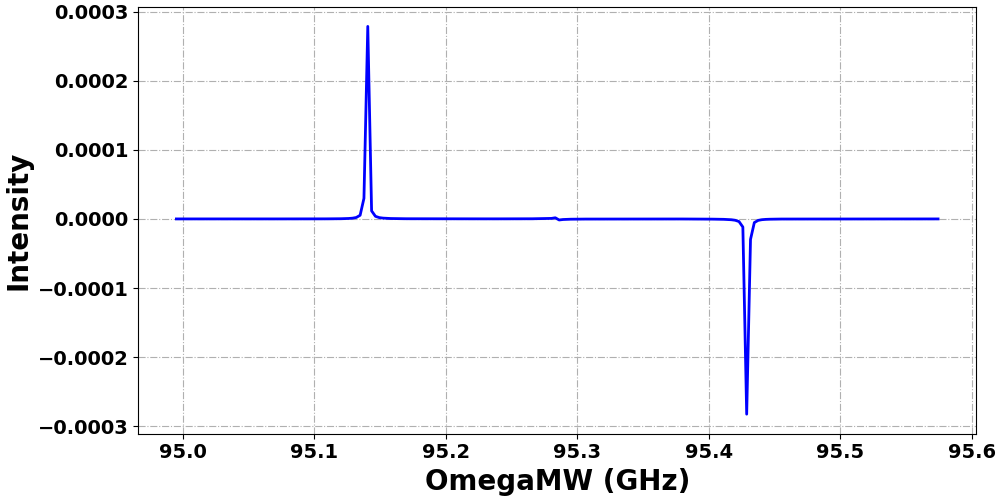

In [5]:

QS.Plotting.Plotting_SpanSelector(Omega_MW * 1.0e-9 /(2.0*QS.pi),Intensity,"OmegaMW (GHz)","Intensity","blue")